<a href="https://colab.research.google.com/github/Psalmist70/curriculum-alignment-ai/blob/main/curriculum_alignment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Psalmist70/curriculum-alignment-system.github

Cloning into 'curriculum-alignment-system.github'...
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/curriculum-alignment-system/curriculum_cleaned.csv"

df = pd.read_csv(path, encoding="latin1")

df.head()

,course_id,course_title,course_description,program_outcomes,level,semester
0,CPE401,Computer Architecture and Organization,This course examines the structural and functi...,Analyze CPU components; design digital systems...,400,1
1,CSC403,Principles of Compilers,This course introduces the fundamental concept...,Explain compiler stages; implement lexical sca...,400,1
2,CPE405,Introduction to Microprocessor Technology & Mi...,This course focuses on microprocessor systems ...,Design I/O interfaces; manage interrupt struct...,400,1
3,CSC407,Techniques in Software Development,This course provides an overview of software d...,Apply software design principles; practice sof...,400,1
4,CPE409,Microprocessor Design Laboratory,This course involves practical implementation ...,Apply architectural theory; execute microcontr...,400,1


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   course_id           23 non-null     object
 1   course_title        23 non-null     object
 2   course_description  23 non-null     object
 3   program_outcomes    23 non-null     object
 4   level               23 non-null     int64 
 5   semester            23 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 1.2+ KB


In [ ]:
df["desc_length"] = df["course_description"].astype(str).apply(len)
df["desc_length"].describe()

,desc_length
count,23.000000
mean,405.000000
std,127.544288
min,245.000000
25%,322.000000
50%,373.000000
75%,439.500000
max,709.000000


In [ ]:
df["course_title"] = df["course_title"].astype(str)
df["course_description"] = df["course_description"].astype(str)

In [ ]:
if "program_outcomes" in df.columns:
      df["program_outcomes"] = df["program_outcomes"].astype(str)

In [ ]:
df["course_description"] = df["course_description"].str.lower()
df["program_outcomes"] = df["program_outcomes"].str.lower()

In [ ]:
df["course_description"] = df["course_description"].str.replace("\n", " ")
df["program_outcomes"] = df["program_outcomes"].str.replace("\n", " ")

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/curriculum-alignment-system/kaggle_jobs.csv"

df = pd.read_csv(path)

df.head()

,location,Job Posting Date,Job Title,Role,Job Description,skills,Company,experience_min,experience_max,qualification_level,salary_min,salary_max
0,Ashgabat,2022-12-19,Web Developer,Frontend Web Developer,Frontend Web Developers design and implement u...,"['css', 'html', 'javascript']",PNC Financial Services Group,2,12,bachelors,56000,116000
1,Macao,2022-09-14,Operations Manager,Quality Control Manager,Quality Control Managers establish and enforce...,['compliance'],United Services Automobile Assn.,0,12,phd,61000,104000
2,George Town,2023-04-10,Teacher,Classroom Teacher,A Classroom Teacher educates students in a spe...,"['assessment', 'teaching']",FedEx,3,15,phd,63000,103000
3,SÃ£o TomÃ©,2022-09-20,UX/UI Designer,User Interface Designer,User Interface Designers focus on the visual a...,['typography'],Ryder System,2,8,other,65000,102000
4,Male,2022-02-19,UX/UI Designer,Interaction Designer,Interaction Designers specialize in designing ...,"['prototyping', 'wireframing']",Zee Entertainment Enterprises,2,9,other,65000,102000


In [ ]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1145965 entries, 0 to 1145964
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   location             1145965 non-null  object
 1   Job Posting Date     1145965 non-null  object
 2   Job Title            1145965 non-null  object
 3   Role                 1145965 non-null  object
 4   Job Description      1145965 non-null  object
 5   skills               1145965 non-null  object
 6   Company              1145965 non-null  object
 7   experience_min       1145965 non-null  int64 
 8   experience_max       1145965 non-null  int64 
 9   qualification_level  1145965 non-null  object
 10  salary_min           1145965 non-null  int64 
 11  salary_max           1145965 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 104.9+ MB


Index(['location', 'Job Posting Date', 'Job Title', 'Role', 'Job Description',
       'skills', 'Company', 'experience_min', 'experience_max',
       'qualification_level', 'salary_min', 'salary_max'],
      dtype='object')

In [ ]:
df = df[[
      "Job Title",
      "Job Description",
      "skills"
]]

In [ ]:
df.columns = ["job_title", "job_description", "skills"]

In [ ]:
df.dropna(inplace=True)

In [ ]:
df["job_title"] = df["job_title"].str.lower().str.strip()
df["job_description"] = df["job_description"].str.lower().str.strip()
df["skills"] = df["skills"].str.lower().str.strip()

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
len(df)

1145965

In [ ]:
df = df.sample(n=50000, random_state=42)

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
save_path = "/content/drive/MyDrive/curriculum-alignment-system/job_datasetfull_cleaned.csv"
df.to_csv(save_path, index=False)

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/curriculum-alignment-system/job_dataset_cleaned.csv"

df_kaggle = pd.read_csv(path)
df_kaggle.head()

,job_title,job_description,skills
0,web developer,frontend web developers design and implement u...,"['css', 'html', 'javascript']"
1,operations manager,quality control managers establish and enforce...,['compliance']
2,teacher,a classroom teacher educates students in a spe...,"['assessment', 'teaching']"
3,ux/ui designer,user interface designers focus on the visual a...,['typography']
4,ux/ui designer,interaction designers specialize in designing ...,"['prototyping', 'wireframing']"


In [ ]:
APP_ID = "42f8d797"
APP_KEY = "b50a2dae17cf36cc29d2261c6de142cd"

In [ ]:
import requests

def fetch_adzuna_jobs(query, page=1):
    url = f"https://api.adzuna.com/v1/api/jobs/us/search/{page}"

    params = {
        "app_id": APP_ID,
        "app_key": APP_KEY,
        "results_per_page": 50,
        "what": query,
        "content-type": "application/json"
    }

    response = requests.get(url, params=params)
    return response.json()

In [ ]:
queries = [
      "software engineer",
      "data analyst",
      "machine learning",
      "cybersecurity"
]
adzuna_jobs = []

for q in queries:
    data = fetch_adzuna_jobs(q)

    for job in data.get("results", []):
        adzuna_jobs.append({
             "job_title": job.get("title", ""),
             "job_description": job.get("description", ""),
             "skills": "",  # API does not always provide structured skills
             "source": "adzuna"
        })

In [ ]:
df_adzuna = pd.DataFrame(adzuna_jobs)
df_adzuna.head()

,job_title,job_description,skills,source
0,Software Engineering,L3Harris is dedicated to recruiting and develo...,,adzuna
1,Software Engineering,L3Harris is dedicated to recruiting and develo...,,adzuna
2,Software Engineering,L3Harris is dedicated to recruiting and develo...,,adzuna
3,Software Engineering,L3Harris is dedicated to recruiting and develo...,,adzuna
4,Software Engineering,L3Harris is dedicated to recruiting and develo...,,adzuna


In [ ]:
len(adzuna_jobs)

200

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/curriculum-alignment-system/job_datasetfull_cleaned.csv"

df = pd.read_csv(path)

df.head()

,job_title,job_description,skills
0,web developer,frontend web developers design and implement u...,"['css', 'html', 'javascript']"
1,operations manager,quality control managers establish and enforce...,['compliance']
2,teacher,a classroom teacher educates students in a spe...,"['assessment', 'teaching']"
3,ux/ui designer,user interface designers focus on the visual a...,['typography']
4,ux/ui designer,interaction designers specialize in designing ...,"['prototyping', 'wireframing']"


In [ ]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1145965 entries, 0 to 1145964
Data columns (total 3 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   job_title        1145965 non-null  object
 1   job_description  1145965 non-null  object
 2   skills           1145965 non-null  object
dtypes: object(3)
memory usage: 26.2+ MB


Index(['job_title', 'job_description', 'skills'], dtype='object')

In [ ]:
df.isnull().sum()

,0
job_title,0
job_description,0
skills,0


In [ ]:
df["job_title"] = df["job_title"].str.lower().str.strip()
df["job_description"] = df["job_description"].str.lower().str.strip()
df["skills"] = df["skills"].str.lower().str.strip()

In [ ]:
df.duplicated().sum()

np.int64(1145696)

In [ ]:
df = df.drop_duplicates(subset=["job_description"])

In [ ]:
len(df)

269

Now the training start!!!

In [ ]:
import pandas as pd

curriculum_path = "/content/drive/MyDrive/curriculum-alignment-system/curriculum_cleaned.csv"

curriculum_df = pd.read_csv(curriculum_path, encoding="latin1")

curriculum_df.head()

,course_id,course_title,course_description,program_outcomes,level,semester
0,CPE401,Computer Architecture and Organization,This course examines the structural and functi...,Analyze CPU components; design digital systems...,400,1
1,CSC403,Principles of Compilers,This course introduces the fundamental concept...,Explain compiler stages; implement lexical sca...,400,1
2,CPE405,Introduction to Microprocessor Technology & Mi...,This course focuses on microprocessor systems ...,Design I/O interfaces; manage interrupt struct...,400,1
3,CSC407,Techniques in Software Development,This course provides an overview of software d...,Apply software design principles; practice sof...,400,1
4,CPE409,Microprocessor Design Laboratory,This course involves practical implementation ...,Apply architectural theory; execute microcontr...,400,1


In [ ]:
job_path = "/content/drive/MyDrive/curriculum-alignment-system/job_dataset_cleaned.csv"

job_df = pd.read_csv(job_path)

job_df.head()

,job_title,job_description,skills
0,web developer,frontend web developers design and implement u...,"['css', 'html', 'javascript']"
1,operations manager,quality control managers establish and enforce...,['compliance']
2,teacher,a classroom teacher educates students in a spe...,"['assessment', 'teaching']"
3,ux/ui designer,user interface designers focus on the visual a...,['typography']
4,ux/ui designer,interaction designers specialize in designing ...,"['prototyping', 'wireframing']"


In [ ]:
!pip install nltk spacy sentence-transformers scikit-learn -q

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [ ]:
curriculum_df["processed_text"] = (
    curriculum_df["course_description"]
    + " "
    + curriculum_df["program_outcomes"]
)

curriculum_df["processed_text"] = curriculum_df["processed_text"].apply(preprocess_text)

In [ ]:
job_df["processed_text"] = (
    job_df["job_title"]
    + " "
    + job_df["job_description"]
    + " "
    + job_df["skills"]
)

job_df["processed_text"] = job_df["processed_text"].apply(preprocess_text)

In [ ]:
curriculum_df[["course_title", "processed_text"]].head()

,course_title,processed_text
0,Computer Architecture and Organization,course examines structural functional characte...
1,Principles of Compilers,course introduces fundamental concept compiler...
2,Introduction to Microprocessor Technology & Mi...,course focus microprocessor system microprogra...
3,Techniques in Software Development,course provides overview software design conce...
4,Microprocessor Design Laboratory,course involves practical implementation micro...


In [ ]:
job_df[["job_title", "processed_text"]].head()

,job_title,processed_text
0,web developer,web developer frontend web developer design im...
1,operations manager,operation manager quality control manager esta...
2,teacher,teacher classroom teacher educates student spe...
3,ux/ui designer,uxui designer user interface designer focus vi...
4,ux/ui designer,uxui designer interaction designer specialize ...


✔ WHAT YOU JUST COMPLETED

You have now implemented:

✔ Tokenization
✔ Text cleaning
✔ Stopword removal
✔ Lemmatization
✔ Text normalization

This directly satisfies:

Objective 2 — NLP processing and semantic analysis

## **PHASE 5: Skill Extraction (NLP)**

* Extract skills from job descriptions
* Extract key concepts from curriculum
* Use NLP techniques (TF-IDF / spaCy / simple models)

In [ ]:
# Install spaCy
!pip install spacy -q
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 22.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

nlp = spacy.load("en_core_web_sm")

In [ ]:
skill_keywords = [

    # Programming
    "python", "java", "c++", "c", "javascript",
    "php", "typescript", "matlab", "r",

    # Web
    "html", "css", "react", "angular",
    "vue", "nodejs", "django", "flask",

    # Database
    "sql", "mysql", "postgresql",
    "mongodb", "database",

    # AI / Data
    "machine learning", "deep learning",
    "data analysis", "data science",
    "tensorflow", "pytorch", "nlp",

    # Cloud / DevOps
    "aws", "docker", "kubernetes",
    "linux", "git", "api",

    # Security
    "cybersecurity", "network security",

    # UI/UX
    "ui", "ux", "figma",
    "adobe xd", "wireframing",
    "prototyping",

    # Software Engineering
    "oop", "software engineering",
    "testing", "debugging",

    # Networking
    "computer networks", "tcp/ip",

    # Misc
    "problem solving", "communication",
    "teamwork"
]

import re

def extract_skills(text):

    text = str(text).lower()

    found = []

    for skill in skill_keywords:

        pattern = r'\b' + re.escape(skill) + r'\b'

        if re.search(pattern, text):
            found.append(skill)

    return list(set(found))

In [ ]:
job_df["extracted_skills"] = job_df["processed_text"].apply(extract_skills)

In [ ]:
def extract_key_concepts(text):

    doc = nlp(text)

    concepts = []

    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"]:
            concepts.append(token.lemma_.lower())

    return list(set(concepts))

In [ ]:
curriculum_df["key_concepts"] = curriculum_df["processed_text"].apply(extract_key_concepts)

In [ ]:
vectorizer = TfidfVectorizer(max_features=100)

tfidf_matrix = vectorizer.fit_transform(
    curriculum_df["processed_text"]
)

feature_names = vectorizer.get_feature_names_out()

print(feature_names[:50])

['additional' 'algorithm' 'also' 'analysis' 'analytical' 'analyze'
 'application' 'apply' 'architecture' 'assurance' 'compiler'
 'computational' 'computer' 'computing' 'concept' 'configuration' 'course'
 'cover' 'data' 'database' 'design' 'develop' 'development' 'digital'
 'distributed' 'environment' 'examines' 'execute' 'explores' 'focus'
 'functional' 'fundamental' 'graphical' 'hardware' 'implement'
 'implementation' 'include' 'includes' 'including' 'indexing' 'industrial'
 'information' 'interface' 'interrupt' 'introduces' 'involves' 'io'
 'knowledge' 'language' 'library']


In [ ]:
job_df[["job_title", "extracted_skills"]].head()

,job_title,extracted_skills
0,web developer,"[html, javascript]"
1,operations manager,[]
2,teacher,[]
3,ux/ui designer,[]
4,ux/ui designer,"[wireframing, prototyping]"


In [ ]:
curriculum_df[["course_title", "key_concepts"]].head()

,course_title,key_concepts
0,Computer Architecture and Organization,"[mimd, concept, design, cover, course, multipr..."
1,Principles of Compilers,"[approach, concept, design, allocation, scanne..."
2,Introduction to Microprocessor Technology & Mi...,"[raid, microprocessor, design, interface, cour..."
3,Techniques in Software Development,"[software, concept, development, design, inter..."
4,Microprocessor Design Laboratory,"[software, integration, microprocessor, design..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
curriculum_vectors = vectorizer.fit_transform(
    curriculum_df["processed_text"]
)

In [ ]:
job_vectors = vectorizer.transform(
    job_df["processed_text"]
)

## **PHASE 6: Semantic Similarity Analysis**

* Convert text into vectors (embeddings)
* Compare curriculum vs job skills
* Compute similarity scores (cosine similarity)


In [ ]:
# Install sentence-transformers
!pip install sentence-transformers -q

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
curriculum_embeddings = model.encode(
    curriculum_df["processed_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
job_embeddings = model.encode(
    job_df["processed_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/19898 [00:00<?, ?it/s]

In [ ]:
semantic_similarity = cosine_similarity(
    curriculum_embeddings,
    job_embeddings
)

In [ ]:
semantic_similarity.shape

(23, 636730)

# **PHASE 7: Skill Gap Identification**

* Identify missing skills in curriculum
* Highlight weak alignment areas
* Generate gap analysis results


In [ ]:
course_index = 0

top_matches = np.argsort(
    semantic_similarity[course_index]
)[-5:]

In [ ]:
job_df.iloc[top_matches][[
    "job_title",
    "extracted_skills"
]]

,job_title,extracted_skills
128273,network security specialist,"[cybersecurity, network security]"
297556,network security specialist,"[cybersecurity, network security]"
621154,network security specialist,"[cybersecurity, network security]"
565015,network security specialist,"[cybersecurity, network security]"
439619,network security specialist,"[cybersecurity, network security]"


In [ ]:
for idx in top_matches:

    print("Job Title:", job_df.iloc[idx]["job_title"])

    print(
        "Similarity Score:",
        semantic_similarity[course_index][idx]
    )

    print("-" * 50)

Job Title: network security specialist
Similarity Score: 0.3664661
--------------------------------------------------
Job Title: network security specialist
Similarity Score: 0.3664661
--------------------------------------------------
Job Title: network security specialist
Similarity Score: 0.3664661
--------------------------------------------------
Job Title: network security specialist
Similarity Score: 0.3664661
--------------------------------------------------
Job Title: network security specialist
Similarity Score: 0.3664661
--------------------------------------------------


In [ ]:
curriculum_skills = set()

for skills in curriculum_df["key_concepts"]:
    curriculum_skills.update(skills)

In [ ]:
industry_skills = set()

for skills in job_df["extracted_skills"]:
    industry_skills.update(skills)

In [ ]:
skill_gaps = industry_skills - curriculum_skills

In [ ]:
list(skill_gaps)[:50]

['react',
 'java',
 'data analysis',
 'figma',
 'angular',
 'machine learning',
 'python',
 'network security',
 'aws',
 'sql',
 'ux',
 'wireframing',
 'html',
 'ui',
 'prototyping',
 'javascript']

In [ ]:
from collections import Counter

all_skills = []

for skills in job_df["extracted_skills"]:
    all_skills.extend(skills)

skill_frequency = Counter(all_skills)

In [ ]:
skill_frequency.most_common(20)

[('communication', 250587),
 ('prototyping', 36856),
 ('wireframing', 32931),
 ('html', 15432),
 ('sql', 15286),
 ('javascript', 13619),
 ('database', 13385),
 ('network security', 9769),
 ('cybersecurity', 7774),
 ('ui', 7740),
 ('java', 5863),
 ('react', 5722),
 ('angular', 5722),
 ('testing', 3898),
 ('figma', 3894),
 ('aws', 1982),
 ('data analysis', 1979),
 ('ux', 1979),
 ('machine learning', 1840),
 ('python', 1840)]

In [ ]:
alignment_scores = semantic_similarity.max(axis=1)

curriculum_df["alignment_score"] = alignment_scores

In [ ]:
curriculum_df[[
    "course_title",
    "alignment_score"
]]

,course_title,alignment_score
0,Computer Architecture and Organization,0.366466
1,Principles of Compilers,0.397028
2,Introduction to Microprocessor Technology & Mi...,0.391810
3,Techniques in Software Development,0.472016
4,Microprocessor Design Laboratory,0.388848
5,Operating Systems and System Programming,0.451053
6,Individual Project I/II,0.471718
7,Object-Oriented Systems Design,0.555428
8,Industrial Application Studies,0.392602
9,Computers in Society,0.527264


In [ ]:
curriculum_df.to_csv(
    "/content/drive/MyDrive/curriculum-alignment-system/curriculum_analysis_results.csv",
    index=False
)

job_df.to_csv(
    "/content/drive/MyDrive/curriculum-alignment-system/job_analysis_results.csv",
    index=False
)

## **PHASE 8: Knowledge Representation**

* Map relationships (course → skill → job role)
* Structure results logically (basic ontology or mapping table)


In [ ]:
knowledge_mapping = []

In [ ]:
knowledge_mapping = []

for i, row in curriculum_df.iterrows():

    course = row["course_title"]

    course_skills = row["key_concepts"]

    # Sort similarity scores (highest first)
    sorted_indices = np.argsort(
        semantic_similarity[i]
    )[::-1]

    unique_jobs = []
    seen_titles = set()

    # Get top 3 unique job roles
    for idx in sorted_indices:

        title = job_df.iloc[idx]["job_title"]

        if title not in seen_titles:

            unique_jobs.append(idx)
            seen_titles.add(title)

        if len(unique_jobs) == 3:
            break

    # Build mapping table
    for job_idx in unique_jobs:

        job_role = job_df.iloc[job_idx]["job_title"]

        job_skills = job_df.iloc[job_idx]["extracted_skills"]

        similarity_score = semantic_similarity[i][job_idx]

        knowledge_mapping.append({

            "course": course,

            "course_skills": ", ".join(course_skills),

            "job_role": job_role,

            "job_skills": ", ".join(job_skills),

            "similarity_score": similarity_score
        })

In [ ]:
knowledge_df = pd.DataFrame(knowledge_mapping)
knowledge_df.head()

,course,course_skills,job_role,job_skills,similarity_score
0,Computer Architecture and Organization,"mimd, concept, design, cover, course, multipro...",network security specialist,"cybersecurity, network security",0.366466
1,Computer Architecture and Organization,"mimd, concept, design, cover, course, multipro...",aerospace engineer,,0.350006
2,Computer Architecture and Organization,"mimd, concept, design, cover, course, multipro...",network administrator,communication,0.335116
3,Principles of Compilers,"approach, concept, design, allocation, scanner...",java developer,java,0.397028
4,Principles of Compilers,"approach, concept, design, allocation, scanner...",database developer,"sql, database",0.361321


In [ ]:
knowledge_df.to_csv(
    "/content/drive/MyDrive/curriculum-alignment-system/knowledge_mapping.csv",
    index=False
)

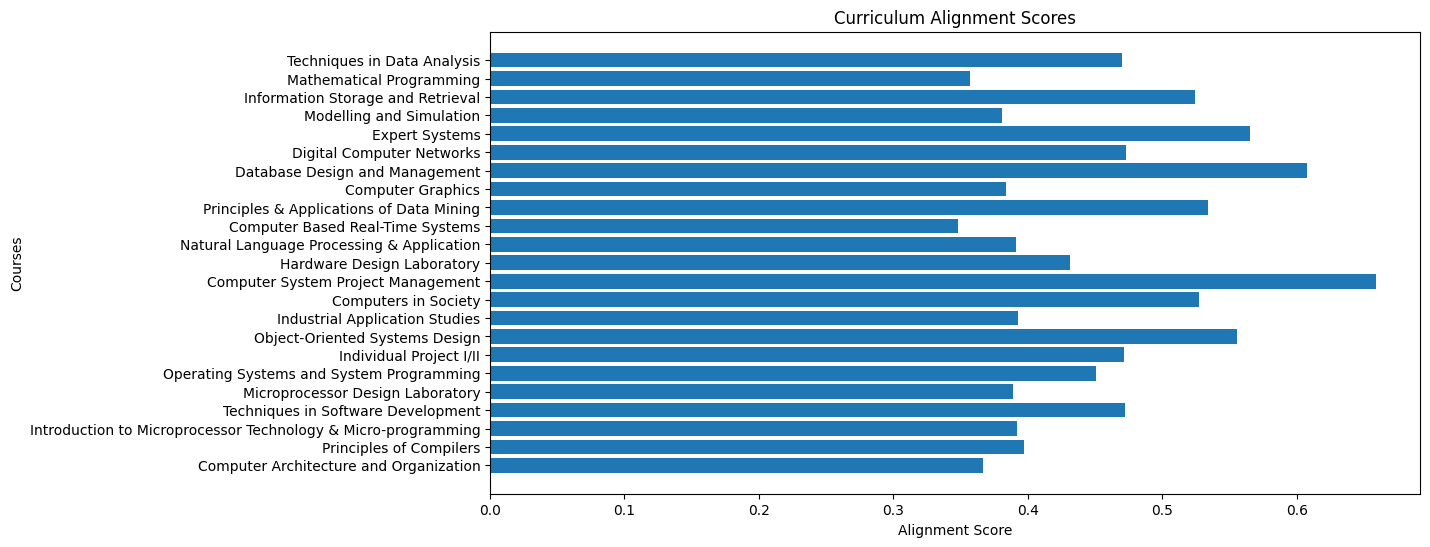

In [ ]:
import matplotlib.pyplot as plt

top_courses = curriculum_df[[
    "course_title",
    "alignment_score"
]]

plt.figure(figsize=(12,6))

plt.barh(
    top_courses["course_title"],
    top_courses["alignment_score"]
)

plt.xlabel("Alignment Score")
plt.ylabel("Courses")

plt.title("Curriculum Alignment Scores")

plt.show()